In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/healthcare_dataset.csv.xls')

In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (55500, 15)

Column Names:
Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

First 5 Records:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [10]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')


df['Billing Amount'] = df['Billing Amount'].fillna(
    df['Billing Amount'].median()
)

In [8]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'], errors='coerce'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'], errors='coerce'
)

df['Date of Admission'] = df['Date of Admission'].ffill()
df['Discharge Date'] = df['Discharge Date'].ffill()


In [9]:
df['Hospital Stay Days'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

print("\nHospital Stay Statistics:")
print(df['Hospital Stay Days'].describe())


Hospital Stay Statistics:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Hospital Stay Days, dtype: float64


In [11]:
df['Admission Type'] = df['Admission Type'].str.strip().str.title()

# Keep only required admission categories
df['Urgency Category'] = df['Admission Type'].replace({
    'Emergency': 'Emergency',
    'Urgent': 'Urgent',
    'Elective': 'Elective'
})

print("\nAdmission Categories:")
print(df['Urgency Category'].value_counts())


Admission Categories:
Urgency Category
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


In [12]:
print("\nBilling Amount Statistics:")
print(df['Billing Amount'].describe())

# Mean, Median and Standard Deviation
print("\nMean Billing Amount:",
      df['Billing Amount'].mean())

print("Median Billing Amount:",
      df['Billing Amount'].median())

print("Standard Deviation:",
      df['Billing Amount'].std())


Billing Amount Statistics:
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: Billing Amount, dtype: float64

Mean Billing Amount: 25539.316097211795
Median Billing Amount: 25538.069375965664
Standard Deviation: 14211.45443086446


In [13]:
demographics = df.groupby('Medical Condition').agg(
    Patients=('Name', 'count'),
    Average_Age=('Age', 'mean'),
    Male=('Gender', lambda x: (x == 'Male').sum()),
    Female=('Gender', lambda x: (x == 'Female').sum()),
    Average_Billing=('Billing Amount', 'mean'),
    Average_Stay=('Hospital Stay Days', 'mean')
)

print("\nDemographics by Medical Condition:")
display(demographics)


Demographics by Medical Condition:


,Patients,Average_Age,Male,Female,Average_Billing,Average_Stay
Medical Condition,,,,,,
Arthritis,9308,51.565320,4622,4686,25497.327056,15.517404
Asthma,9185,51.575830,4632,4553,25635.249359,15.696570
Cancer,9227,51.558795,4625,4602,25161.792707,15.495827
Diabetes,9304,51.554170,4653,4651,25638.405577,15.422936
Hypertension,9245,51.741915,4633,4612,25497.095761,15.458626
Obesity,9231,51.240277,4609,4622,25805.971259,15.464305


In [14]:
condition_count = df['Medical Condition'].value_counts()

print("\nPatients by Medical Condition:")
print(condition_count)



Patients by Medical Condition:
Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64


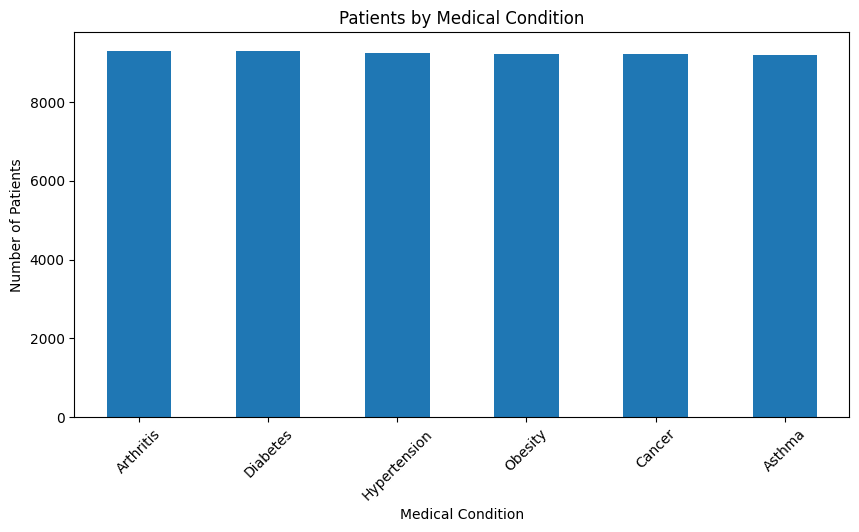

In [15]:
plt.figure(figsize=(10,5))
condition_count.plot(kind='bar')
plt.title('Patients by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

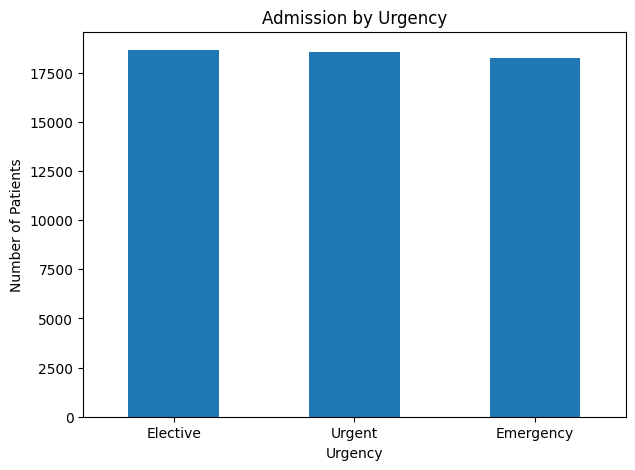

In [16]:
plt.figure(figsize=(7,5))
df['Urgency Category'].value_counts().plot(kind='bar')
plt.title('Admission by Urgency')
plt.xlabel('Urgency')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.show()


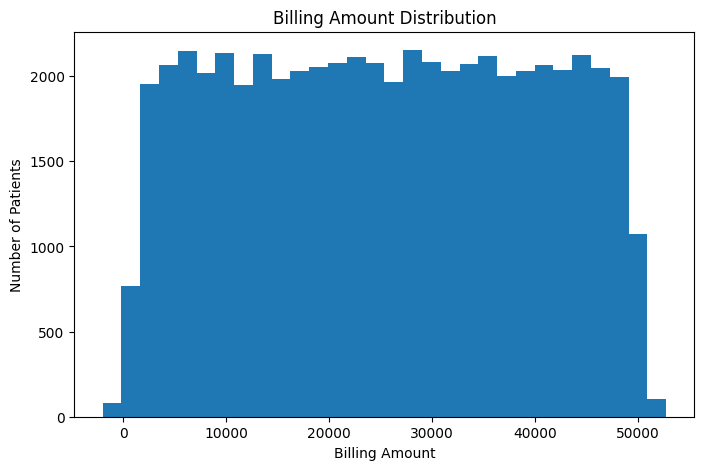

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df['Billing Amount'], bins=30)
plt.title('Billing Amount Distribution')
plt.xlabel('Billing Amount')
plt.ylabel('Number of Patients')
plt.show()

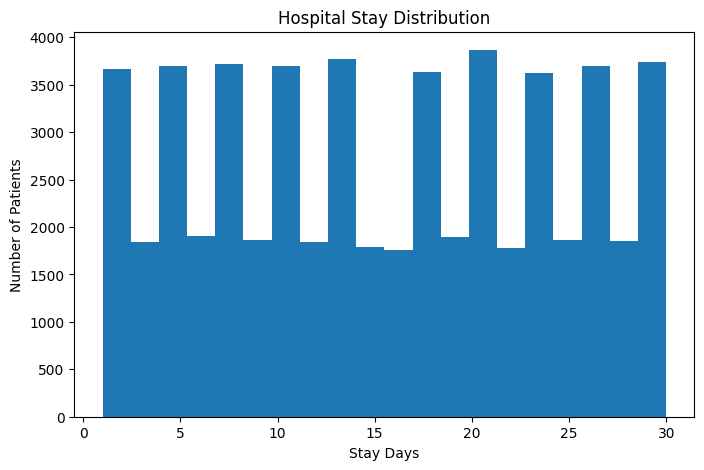

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df['Hospital Stay Days'], bins=20)
plt.title('Hospital Stay Distribution')
plt.xlabel('Stay Days')
plt.ylabel('Number of Patients')
plt.show()

In [19]:
print("\nFinal Dataset:")
display(df.head())

print("\nFinal Shape:", df.shape)


Final Dataset:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Hospital Stay Days,Urgency Category
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,Urgent
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,Emergency
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,Emergency
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30,Elective
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20,Urgent



Final Shape: (55500, 17)
